In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/__results__.html
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/__output__.json
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/custom.css
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/5_min/y.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/5_min/X.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/15_min/y.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/15_min/X.npy
/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset/25_min/y.n

In [2]:
# ============================================================
# Install Required Packages
# ============================================================

!pip -q install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 2.7 MB/s eta 0:00:00


In [3]:
# ============================================================
# Imports
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from scipy.signal import hilbert

from PIL import Image

from PyEMD import EMD

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# Dataset Paths
# ============================================================

DATA_ROOT = "/kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset"

OUTPUT_ROOT = "/kaggle/working/Hilbert_Dataset"

prediction_windows = [30,25,20,15,10,5]

os.makedirs(
    OUTPUT_ROOT,
    exist_ok=True
)

print("Input :", DATA_ROOT)
print("Output:", OUTPUT_ROOT)

Input : /kaggle/input/notebooks/mdrashidshahariar/notebook-04-dataset-preparation-preprocessing/Prepared_Dataset
Output: /kaggle/working/Hilbert_Dataset


In [5]:
# ============================================================
# Configuration
# ============================================================

FS = 250

IMAGE_SIZE = (224,224)

MAX_IMFS = 6

LEAD = 0

print("Sampling Rate :", FS)

print("Maximum IMFs :", MAX_IMFS)

print("Image Size :", IMAGE_SIZE)

print("Using Lead :", LEAD)

Sampling Rate : 250
Maximum IMFs : 6
Image Size : (224, 224)
Using Lead : 0


In [6]:
def load_dataset(minute):

    folder = os.path.join(
        DATA_ROOT,
        f"{minute}_min"
    )

    X = np.load(os.path.join(folder, "X.npy"))
    y = np.load(os.path.join(folder, "y.npy"))

    return X, y

In [7]:
# ============================================================
# Verify Dataset
# ============================================================

X, y = load_dataset(30)

print("ECG Shape :", X.shape)

print("Labels :", y.shape)

print("Positive :", np.sum(y==1))

print("Negative :", np.sum(y==0))

print()

print("One ECG Shape :", X[0].shape)

print("Data Type :", X.dtype)

ECG Shape : (2400, 500, 2)
Labels : (2400,)
Positive : 1200
Negative : 1200

One ECG Shape : (500, 2)
Data Type : float64


In [8]:
# ============================================================
# Empirical Mode Decomposition
# ============================================================

def perform_emd(ecg):

    # Use Lead-I
    signal = ecg[:, LEAD]

    emd = EMD()

    imfs = emd(signal)

    return signal, imfs

In [9]:
# ============================================================
# Test EMD
# ============================================================

signal, imfs = perform_emd(X[0])

print("Original Signal Shape :", signal.shape)

print("Number of IMFs :", len(imfs))

for i, imf in enumerate(imfs):
    print(f"IMF {i+1} Shape :", imf.shape)

Original Signal Shape : (500,)
Number of IMFs : 7
IMF 1 Shape : (500,)
IMF 2 Shape : (500,)
IMF 3 Shape : (500,)
IMF 4 Shape : (500,)
IMF 5 Shape : (500,)
IMF 6 Shape : (500,)
IMF 7 Shape : (500,)


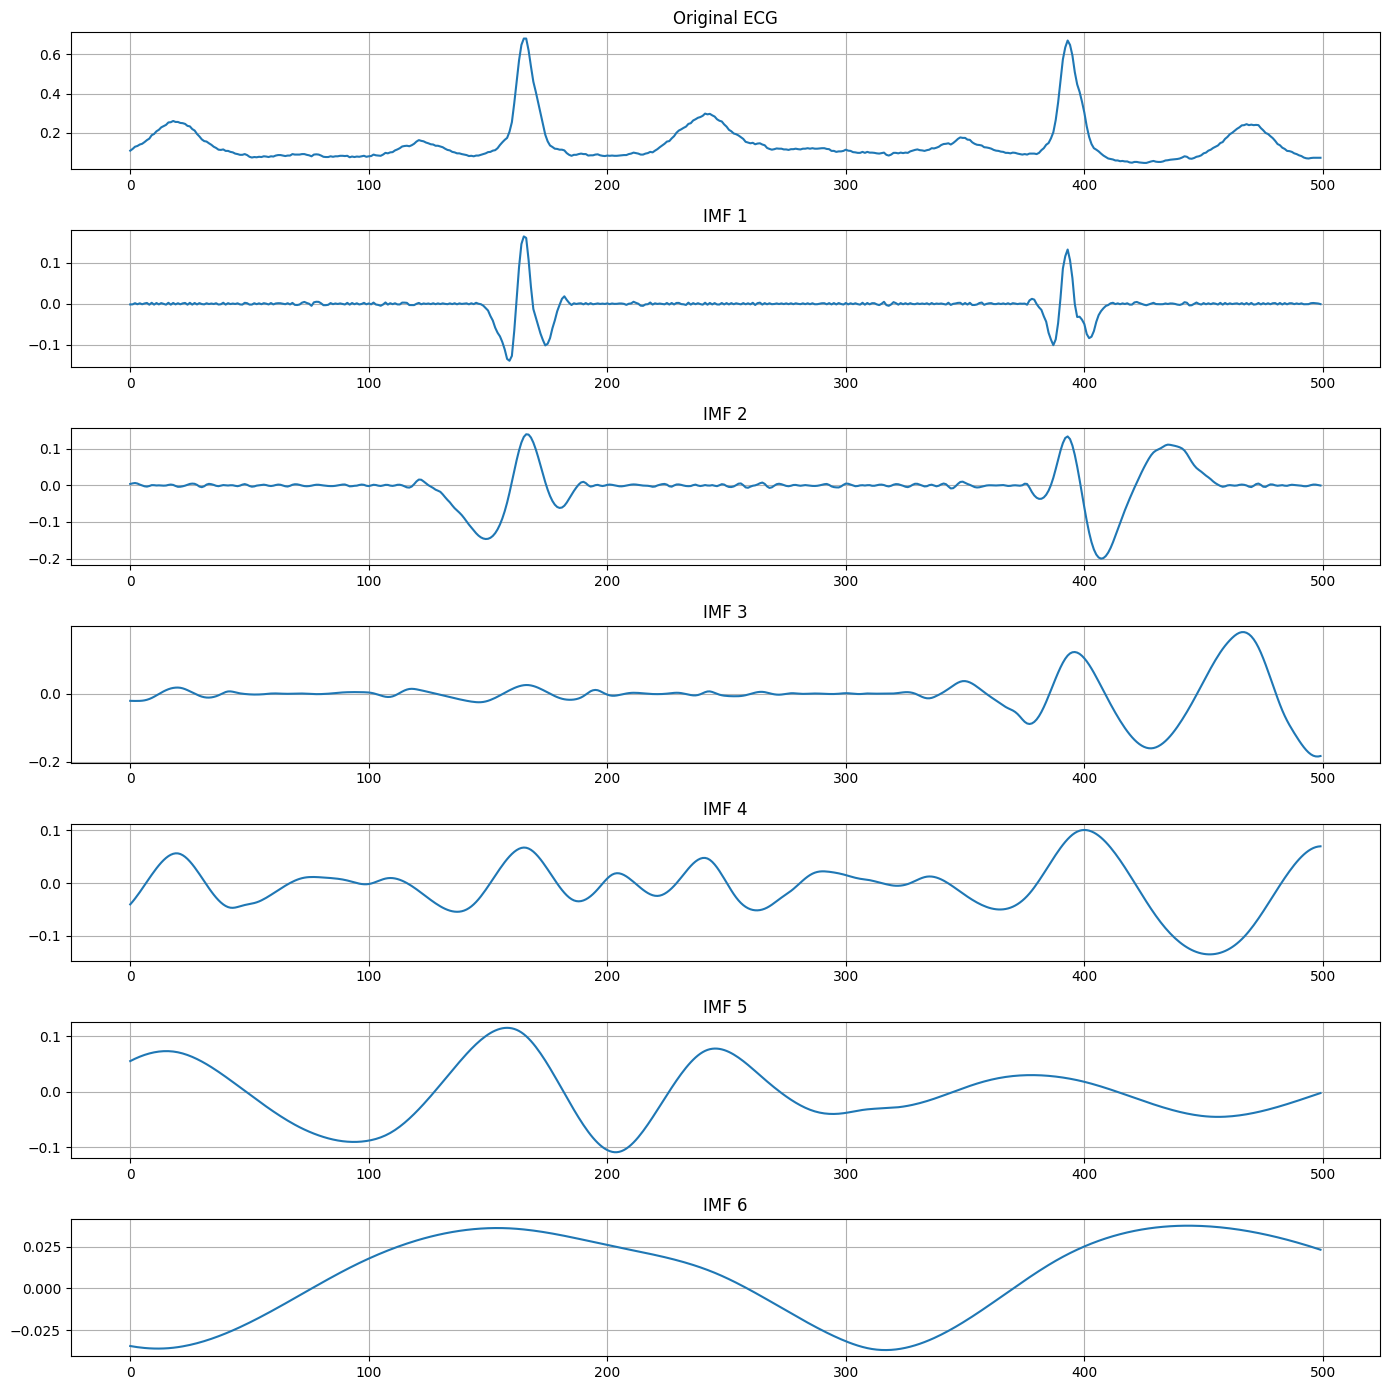

In [10]:
# ============================================================
# Visualize EMD Decomposition
# ============================================================

num_plots = min(len(imfs), MAX_IMFS)

plt.figure(figsize=(14, 2 * (num_plots + 1)))

# Original ECG
plt.subplot(num_plots + 1, 1, 1)
plt.plot(signal)
plt.title("Original ECG")
plt.grid(True)

# IMFs
for i in range(num_plots):

    plt.subplot(num_plots + 1, 1, i + 2)

    plt.plot(imfs[i])

    plt.title(f"IMF {i+1}")

    plt.grid(True)

plt.tight_layout()

plt.show()

In [11]:
# ============================================================
# Perform Empirical Mode Decomposition (EMD)
# ============================================================

from PyEMD import EMD

def perform_emd(ecg):
    """
    Perform EMD on one ECG segment.

    Parameters
    ----------
    ecg : ndarray
        ECG segment of shape (500, 2)

    Returns
    -------
    signal : ndarray
        Selected ECG lead (500,)
    imfs : ndarray
        Intrinsic Mode Functions (n_imfs, 500)
    """

    # Select one ECG lead
    signal = ecg[:, LEAD].astype(np.float64)

    # Create EMD object
    emd = EMD()

    # Decompose signal
    imfs = emd(signal)

    # Ensure 2D output
    if imfs.ndim == 1:
        imfs = imfs[np.newaxis, :]

    return signal, imfs

In [12]:
# ============================================================
# Generate Hilbert Spectrum (Standard HHT)
# ============================================================

from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter

def generate_hilbert_spectrum(
    imfs,
    fs=250,
    freq_bins=224,
    max_freq=125
):

    n_imfs, n_samples = imfs.shape

    spectrum = np.zeros((freq_bins, n_samples))

    for imf in imfs[:MAX_IMFS]:

        # Analytic signal
        analytic = hilbert(imf)

        amplitude = np.abs(analytic)

        phase = np.unwrap(np.angle(analytic))

        # Instantaneous frequency
        inst_freq = np.diff(phase)

        inst_freq = inst_freq * fs / (2*np.pi)

        amplitude = amplitude[:-1]

        for t in range(len(inst_freq)):

            f = inst_freq[t]

            if np.isnan(f):
                continue

            if f < 0:
                continue

            if f > max_freq:
                continue

            row = int(
                (f/max_freq) * (freq_bins-1)
            )

            spectrum[row, t] += amplitude[t]

    # Smooth spectrum (standard visualization)
    spectrum = gaussian_filter(
        spectrum,
        sigma=1.0
    )

    return spectrum

In [13]:
signal, imfs = perform_emd(X[0])

print("Signal Shape :", signal.shape)
print("IMFs Shape   :", imfs.shape)
print("Number of IMFs :", imfs.shape[0])

Signal Shape : (500,)
IMFs Shape   : (7, 500)
Number of IMFs : 7


In [14]:
# ============================================================
# Normalize Hilbert Spectrum
# ============================================================

def normalize_spectrum(spectrum):

    spectrum = np.log1p(spectrum)

    spectrum -= spectrum.min()

    if spectrum.max() > 0:
        spectrum /= spectrum.max()

    return spectrum.astype(np.float32)

In [15]:
# ============================================================
# Test Hilbert Spectrum Generation
# ============================================================

minute = 30

X, y = load_dataset(minute)

signal, imfs = perform_emd(X[0])

spectrum = generate_hilbert_spectrum(
    imfs,
    fs=FS
)

spectrum = normalize_spectrum(spectrum)

print("Signal Shape :", signal.shape)
print("IMFs Shape   :", imfs.shape)
print("Spectrum Shape :", spectrum.shape)

print("Min :", spectrum.min())
print("Max :", spectrum.max())

Signal Shape : (500,)
IMFs Shape   : (7, 500)
Spectrum Shape : (224, 500)
Min : 0.0
Max : 1.0


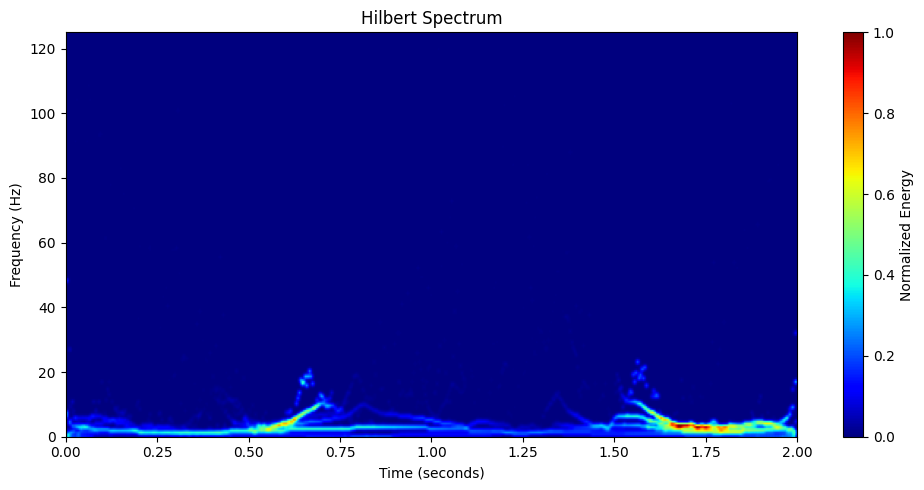

In [16]:
# ============================================================
# Visualize Hilbert Spectrum
# ============================================================

plt.figure(figsize=(10,5))

plt.imshow(
    spectrum,
    origin="lower",
    aspect="auto",
    cmap="jet",
    extent=[0,2,0,125]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("Hilbert Spectrum")

plt.colorbar(label="Normalized Energy")

plt.tight_layout()

plt.show()

In [17]:
# ============================================================
# Create Output Directories
# ============================================================

for minute in prediction_windows:

    os.makedirs(
        os.path.join(
            OUTPUT_ROOT,
            f"{minute}_min",
            "Positive"
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            OUTPUT_ROOT,
            f"{minute}_min",
            "Negative"
        ),
        exist_ok=True
    )

print("Output folders created successfully.")

Output folders created successfully.


In [18]:
# ============================================================
# Save Hilbert Spectrum Image
# ============================================================

from PIL import Image

def save_hilbert_image(spectrum, save_path):

    image = (spectrum * 255).astype(np.uint8)

    image = Image.fromarray(image)

    image = image.resize(
        IMAGE_SIZE,
        Image.BILINEAR
    )

    image = image.convert("RGB")

    image.save(save_path)

In [19]:
# ============================================================
# Generate Hilbert Spectrum Dataset
# ============================================================

for minute in prediction_windows:

    print(f"\nProcessing {minute} Minutes")

    X, y = load_dataset(minute)

    positive_folder = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Positive"
    )

    negative_folder = os.path.join(
        OUTPUT_ROOT,
        f"{minute}_min",
        "Negative"
    )

    positive_count = 0
    negative_count = 0

    for idx in tqdm(range(len(X))):

        signal, imfs = perform_emd(X[idx])

        spectrum = generate_hilbert_spectrum(
            imfs,
            fs=FS
        )

        spectrum = normalize_spectrum(spectrum)

        if y[idx] == 1:

            save_path = os.path.join(
                positive_folder,
                f"{idx:05d}.png"
            )

            positive_count += 1

        else:

            save_path = os.path.join(
                negative_folder,
                f"{idx:05d}.png"
            )

            negative_count += 1

        save_hilbert_image(
            spectrum,
            save_path
        )

    print(f"Positive Images : {positive_count}")
    print(f"Negative Images : {negative_count}")


Processing 30 Minutes


  0%|          | 0/2400 [00:00<?, ?it/s]

Positive Images : 1200
Negative Images : 1200

Processing 25 Minutes


  0%|          | 0/2400 [00:00<?, ?it/s]

Positive Images : 1200
Negative Images : 1200

Processing 20 Minutes


  0%|          | 0/2400 [00:00<?, ?it/s]

ValueError: `y` must contain only finite values.

In [ ]:
# ============================================================
# Verify Generated Images
# ============================================================

summary = []

for minute in prediction_windows:

    positive = len(os.listdir(
        os.path.join(
            OUTPUT_ROOT,
            f"{minute}_min",
            "Positive"
        )
    ))

    negative = len(os.listdir(
        os.path.join(
            OUTPUT_ROOT,
            f"{minute}_min",
            "Negative"
        )
    ))

    summary.append([minute, positive, negative])

summary = pd.DataFrame(
    summary,
    columns=[
        "Prediction Window",
        "Positive Images",
        "Negative Images"
    ]
)

summary

In [20]:
# ============================================================
# Check for NaN / Inf in 20-minute Dataset
# ============================================================

minute = 20

X, y = load_dataset(minute)

bad_indices = []

for idx in range(len(X)):

    signal = X[idx]

    if not np.all(np.isfinite(signal)):

        bad_indices.append(idx)

print(f"Total bad segments: {len(bad_indices)}")

if len(bad_indices) > 0:
    print("First bad segment:", bad_indices[0])

Total bad segments: 11
First bad segment: 629


In [21]:
idx = bad_indices[0]

print("Label:", y[idx])

print("Shape:", X[idx].shape)

print("Minimum:", np.nanmin(X[idx]))

print("Maximum:", np.nanmax(X[idx]))

print("NaN count:", np.isnan(X[idx]).sum())

print("Inf count:", np.isinf(X[idx]).sum())

Label: 1
Shape: (500, 2)
Minimum: -2.5475
Maximum: 2.51625
NaN count: 185
Inf count: 0


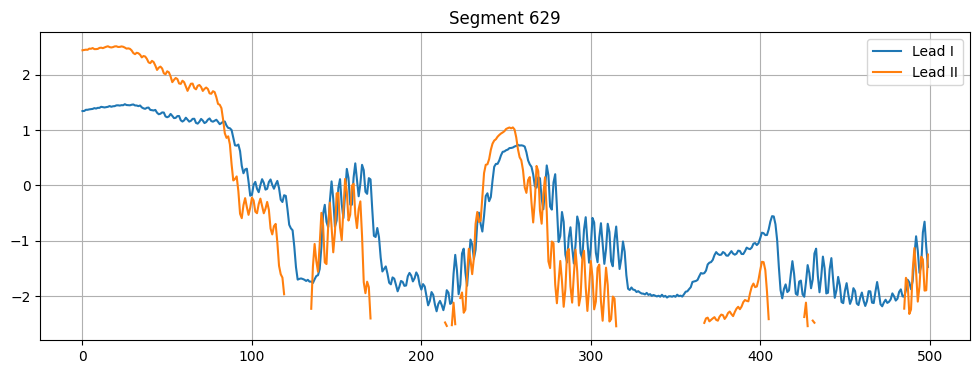

In [22]:
import matplotlib.pyplot as plt

idx = bad_indices[0]

plt.figure(figsize=(12,4))

plt.plot(X[idx][:,0], label="Lead I")

plt.plot(X[idx][:,1], label="Lead II")

plt.legend()

plt.grid(True)

plt.title(f"Segment {idx}")

plt.show()

In [23]:
minute = 20

X, y = load_dataset(minute)

for idx in range(len(X)):

    try:

        signal, imfs = perform_emd(X[idx])

    except Exception as e:

        print("="*60)
        print("Failed at segment:", idx)
        print(type(e).__name__)
        print(e)
        break

Failed at segment: 631
ValueError
`y` must contain only finite values.
